# nb09 — Cross-donor validation and RNA pseudobulk

## Scientific question
Do the CD14 inflammatory and TNF/NF-kB findings recur in additional donors?
How can raw RNA counts be aggregated for later donor-aware population analysis?

## Analysis strategy
Freeze the two discovery-selected programs and the discovery RNA universe/GMT.
Audit donor/site coverage before examining outcomes. Use one common cell-type
reference across eligible donors and captures. Repeat RNA enrichment and paired
RNA–ATAC/RNA–ADT analyses, with site/depth sensitivity and matched-gene removal.
Donor 15078 is discovery, not independent validation. No cross-capture cell matching.

Separately export summed RNA counts by donor × site × cell type × capture, with
cell counts and descriptive normalized means. No condition DE or latent integration.

Copy this notebook, `src/cross_donor.py`, and `src/cross_donor_plots.py` into Drive.
Keep the existing nb04–08 modules and discovery results. Restart a reused runtime.

In [1]:
from pathlib import Path
import sys, subprocess
try:
    from google.colab import drive
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'anndata>=0.11,<0.13'])
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
except ImportError:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from configs.paths import CITE_H5AD, MULTIOME_H5AD
from src.cross_donor import audit_inputs, run_cross_donor
PATHS = {'cite': CITE_H5AD, 'multiome': MULTIOME_H5AD}
DISCOVERY = BASE_PATH / 'results/single_donor'
OUTPUT = BASE_PATH / 'results/cross_donor/nb09_run01'
MIN_CELLS = 50
PERMUTATIONS = 1000
SEED = 42
for path in PATHS.values():
    if not path.is_file():
        raise FileNotFoundError(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Coverage first
Eligibility requires at least 50 CD14 cells and an adequately represented comparator
type in both captures. Reference types are the intersection of discovery-listed
types meeting that threshold in every eligible donor/capture. This is fixed before
outcomes and may differ from nb04; the discovery donor is recomputed consistently.
If fewer than two reference types remain, stop and review rather than silently adapt.
Unresolved labels are excluded and audited. Site-specific RNA tests require the
whole fixed reference to meet the threshold; missing tests remain explicit.

In [2]:
_, _, donors, protocol = audit_inputs(PATHS, DISCOVERY, OUTPUT / 'coverage_audit', MIN_CELLS)
display(donors)
print('Fixed reference types:', protocol['reference_types'])
display(pd.read_csv(OUTPUT / 'coverage_audit/donor_site_coverage.csv'))
print('Independent eligible validation donors:', int(((donors.role == 'validation') & donors.eligible).sum()))

,donor,role,cite_cd14,multiome_cd14,eligible,reason
0,10886,validation,726,704,True,adequate target and comparator coverage
1,11466,validation,6056,674,True,adequate target and comparator coverage
2,12710,validation,1294,1140,True,adequate target and comparator coverage
3,13272,validation,110,0,False,"missing capture, target or comparator coverage"
4,15078,discovery,7244,3243,True,adequate target and comparator coverage
5,16710,validation,2561,1716,True,adequate target and comparator coverage
6,18303,validation,309,1097,True,adequate target and comparator coverage
7,19593,validation,466,458,True,adequate target and comparator coverage
8,28045,validation,2927,208,True,adequate target and comparator coverage
9,28483,validation,0,1603,False,"missing capture, target or comparator coverage"


Fixed reference types: ['B cells', 'CD14 monocytes', 'CD4 T cells', 'CD8 T cells', 'Erythroid populations', 'NK cells']


,DonorID,Site,cell_type_harmonized,n_cells,dataset
0,10886,site1,B cells,446,cite
1,10886,site1,CD14 monocytes,726,cite
2,10886,site1,CD16 monocytes,142,cite
3,10886,site1,CD4 T cells,1367,cite
4,10886,site1,CD8 T cells,554,cite
...,...,...,...,...,...
360,28483,site3,MK/E progenitors,125,multiome
361,28483,site3,NK cells,545,multiome
362,28483,site3,Plasma cells,13,multiome
363,28483,site3,cDC2,83,multiome


Independent eligible validation donors: 7


## Optional local Colab copy
Reading HDF5 repeatedly through Drive can be slow. Copy both inputs once to Colab
local storage when disk space permits. The final outputs still go to Drive.
Copying can take time, especially for Multiome. No files are deleted to make room.

In [3]:
import shutil
COPY_TO_COLAB = str(BASE_PATH).startswith('/content/drive/')
if COPY_TO_COLAB:
    local = Path('/content/nb09_inputs')
    local.mkdir(exist_ok=True)
    required = sum(p.stat().st_size for p in PATHS.values())
    if shutil.disk_usage(local).free < required:
        raise RuntimeError('Insufficient local disk space; use a larger runtime or set COPY_TO_COLAB=False')
    copied = {}
    for capture, source in PATHS.items():
        print('Copying', capture, round(source.stat().st_size / 1e9, 2), 'GB', flush=True)
        destination = local / source.name
        shutil.copyfile(source, destination)
        assert destination.stat().st_size == source.stat().st_size
        copied[capture] = destination
    PATHS = copied

Copying cite 0.62 GB
Copying multiome 3.12 GB


## Run the fixed protocol
This is heavier than nb08: it reads all eligible donor cells, produces pseudobulk,
and performs site-level permutations. Progress is printed by donor/capture.
Raw RNA is selected by feature position, then normalized independently per cell.
ATAC gene activity stays on its stored scale. Protein uses the audited centered-log
panel transform from nb07. Site/depth adjustment is sensitivity analysis, not causality.

All eligible Hallmark sets contribute to BH adjustment in each RNA ranking; only the
two predefined programs are used as primary validation targets. No outcome-based
donor selection. Results for all direct pathway ADTs are saved as exploratory tables;
CD14/CD88/CD54 are the predefined readouts, when their genes belong to the pathway.
Missing membership/coverage is not a zero effect. No new shared leading-edge panel
is selected. RNA–protein leave-one-out removes only the matched gene.

The runner refuses to overwrite a completed or partial run. For a new run, choose
a new OUTPUT folder; there is no automatic resume. Previous results remain available.

[0.0 min] Donor 10886
  cite: raw RNA read; exporting site-resolved pseudobulk
  multiome: raw RNA read; exporting site-resolved pseudobulk
  Scoring P01: CD14 monocytes | Inflammatory Response
  Scoring P02: CD14 monocytes | TNF-alpha Signaling via NF-kB
[8.8 min] Donor 11466
  cite: raw RNA read; exporting site-resolved pseudobulk
  multiome: raw RNA read; exporting site-resolved pseudobulk
  Scoring P01: CD14 monocytes | Inflammatory Response
  Scoring P02: CD14 monocytes | TNF-alpha Signaling via NF-kB
[11.8 min] Donor 12710
  cite: raw RNA read; exporting site-resolved pseudobulk
  multiome: raw RNA read; exporting site-resolved pseudobulk
  Scoring P01: CD14 monocytes | Inflammatory Response
  Scoring P02: CD14 monocytes | TNF-alpha Signaling via NF-kB
[19.9 min] Donor 15078
  cite: raw RNA read; exporting site-resolved pseudobulk
  multiome: raw RNA read; exporting site-resolved pseudobulk
  Scoring P01: CD14 monocytes | Inflammatory Response
  Scoring P02: CD14 monocytes | TNF-

,donor,role,pathway,atac_depth_covariate,cite_NES,cite_q,multiome_NES,multiome_q,atac_adjusted,CD14_module_adjusted,CD14_loo_adjusted,CD88_module_adjusted,CD88_loo_adjusted,CD54_module_adjusted,CD54_loo_adjusted
0,10886,validation,Inflammatory Response,ATAC_nCount_peaks,1.433889,0.010305,1.768258,0.019238,0.442760,0.310624,0.302227,0.332883,0.306522,0.182044,0.177470
1,10886,validation,TNF-alpha Signaling via NF-kB,ATAC_nCount_peaks,1.446872,0.010305,1.697793,0.019238,0.597516,NaN,NaN,NaN,NaN,0.104120,0.101060
2,11466,validation,Inflammatory Response,ATAC_nCount_peaks,1.518825,0.008945,2.240215,0.012126,0.155934,0.174503,0.168358,0.114423,0.094647,0.098624,0.093704
3,11466,validation,TNF-alpha Signaling via NF-kB,ATAC_nCount_peaks,1.567503,0.008945,2.286746,0.012126,0.255287,NaN,NaN,NaN,NaN,0.143977,0.140856
4,12710,validation,Inflammatory Response,ATAC_nCount_peaks,1.397679,0.013742,1.702831,0.019702,0.175742,0.309742,0.302469,0.092750,0.082962,0.236524,0.236772
5,12710,validation,TNF-alpha Signaling via NF-kB,ATAC_nCount_peaks,1.537490,0.012422,1.776432,0.019702,0.193143,NaN,NaN,NaN,NaN,0.193069,0.193380
6,15078,discovery,Inflammatory Response,ATAC_nCount_peaks,1.529943,0.020697,1.575068,0.025000,0.331779,0.269020,0.260139,0.226588,0.207716,0.172183,0.170576
7,15078,discovery,TNF-alpha Signaling via NF-kB,ATAC_nCount_peaks,1.609935,0.014601,1.641548,0.025000,0.475907,NaN,NaN,NaN,NaN,0.155940,0.154783
8,16710,validation,Inflammatory Response,ATAC_nCount_peaks,1.357418,0.010677,1.771881,0.018645,0.088403,0.140327,0.141800,0.119670,0.103346,0.012831,0.007291
9,16710,validation,TNF-alpha Signaling via NF-kB,ATAC_nCount_peaks,1.395357,0.008147,1.773851,0.018645,0.186712,NaN,NaN,NaN,NaN,0.035010,0.030732


,pathway,measurement,n_eligible_validation_donors,n_testable_donors,n_positive_donors,median,minimum,maximum
0,Inflammatory Response,atac_adjusted,7,7,7,0.246606,0.088403,0.442760
1,Inflammatory Response,CD14_module_adjusted,7,7,7,0.309742,0.140327,0.368075
2,Inflammatory Response,CD88_module_adjusted,7,7,7,0.119670,0.092750,0.339622
3,Inflammatory Response,CD54_module_adjusted,7,7,7,0.177645,0.012831,0.346590
4,TNF-alpha Signaling via NF-kB,atac_adjusted,7,7,7,0.373407,0.186712,0.597516
5,TNF-alpha Signaling via NF-kB,CD14_module_adjusted,7,0,0,NaN,NaN,NaN
6,TNF-alpha Signaling via NF-kB,CD88_module_adjusted,7,0,0,NaN,NaN,NaN
7,TNF-alpha Signaling via NF-kB,CD54_module_adjusted,7,7,7,0.143977,0.035010,0.315438


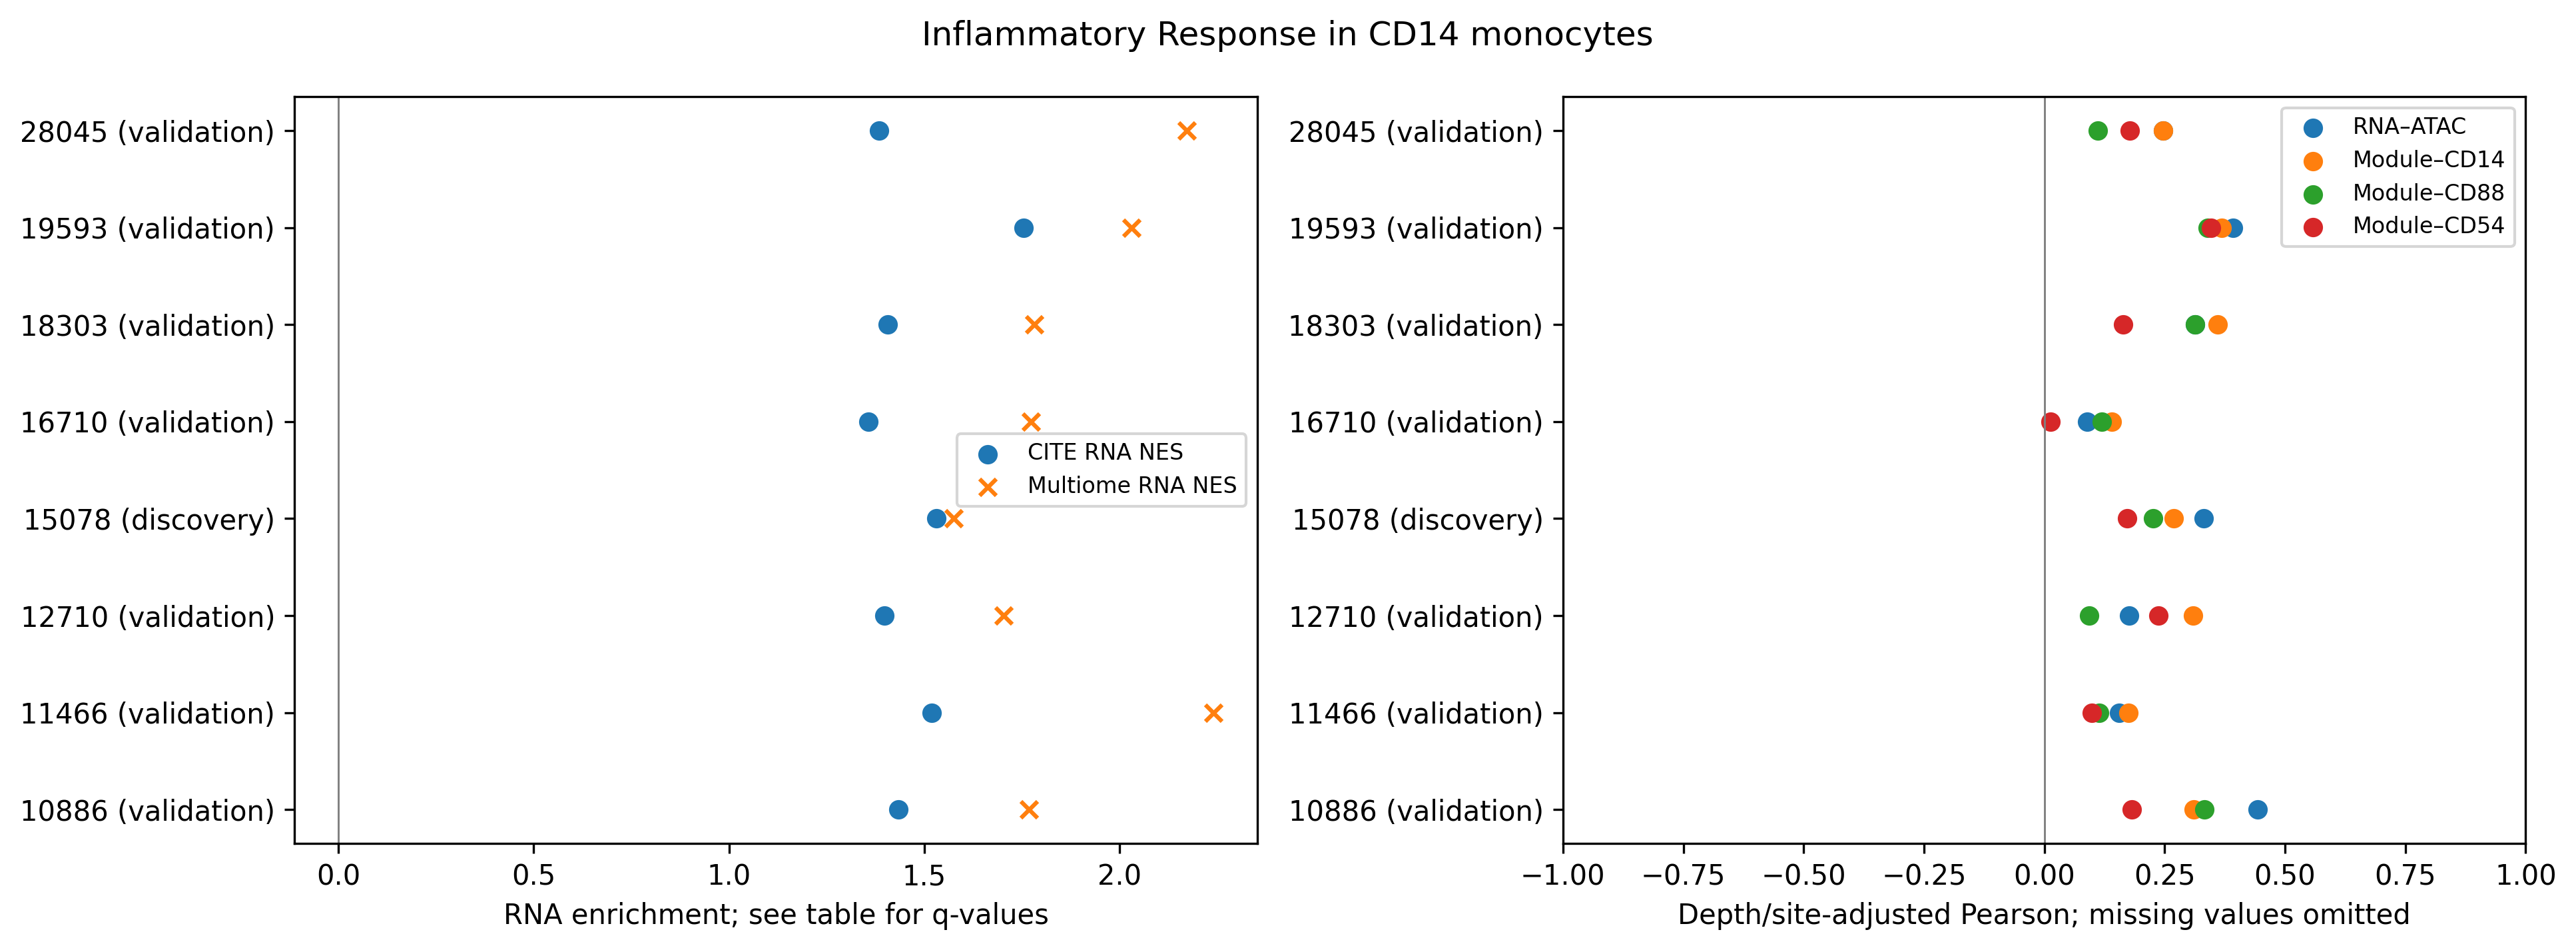

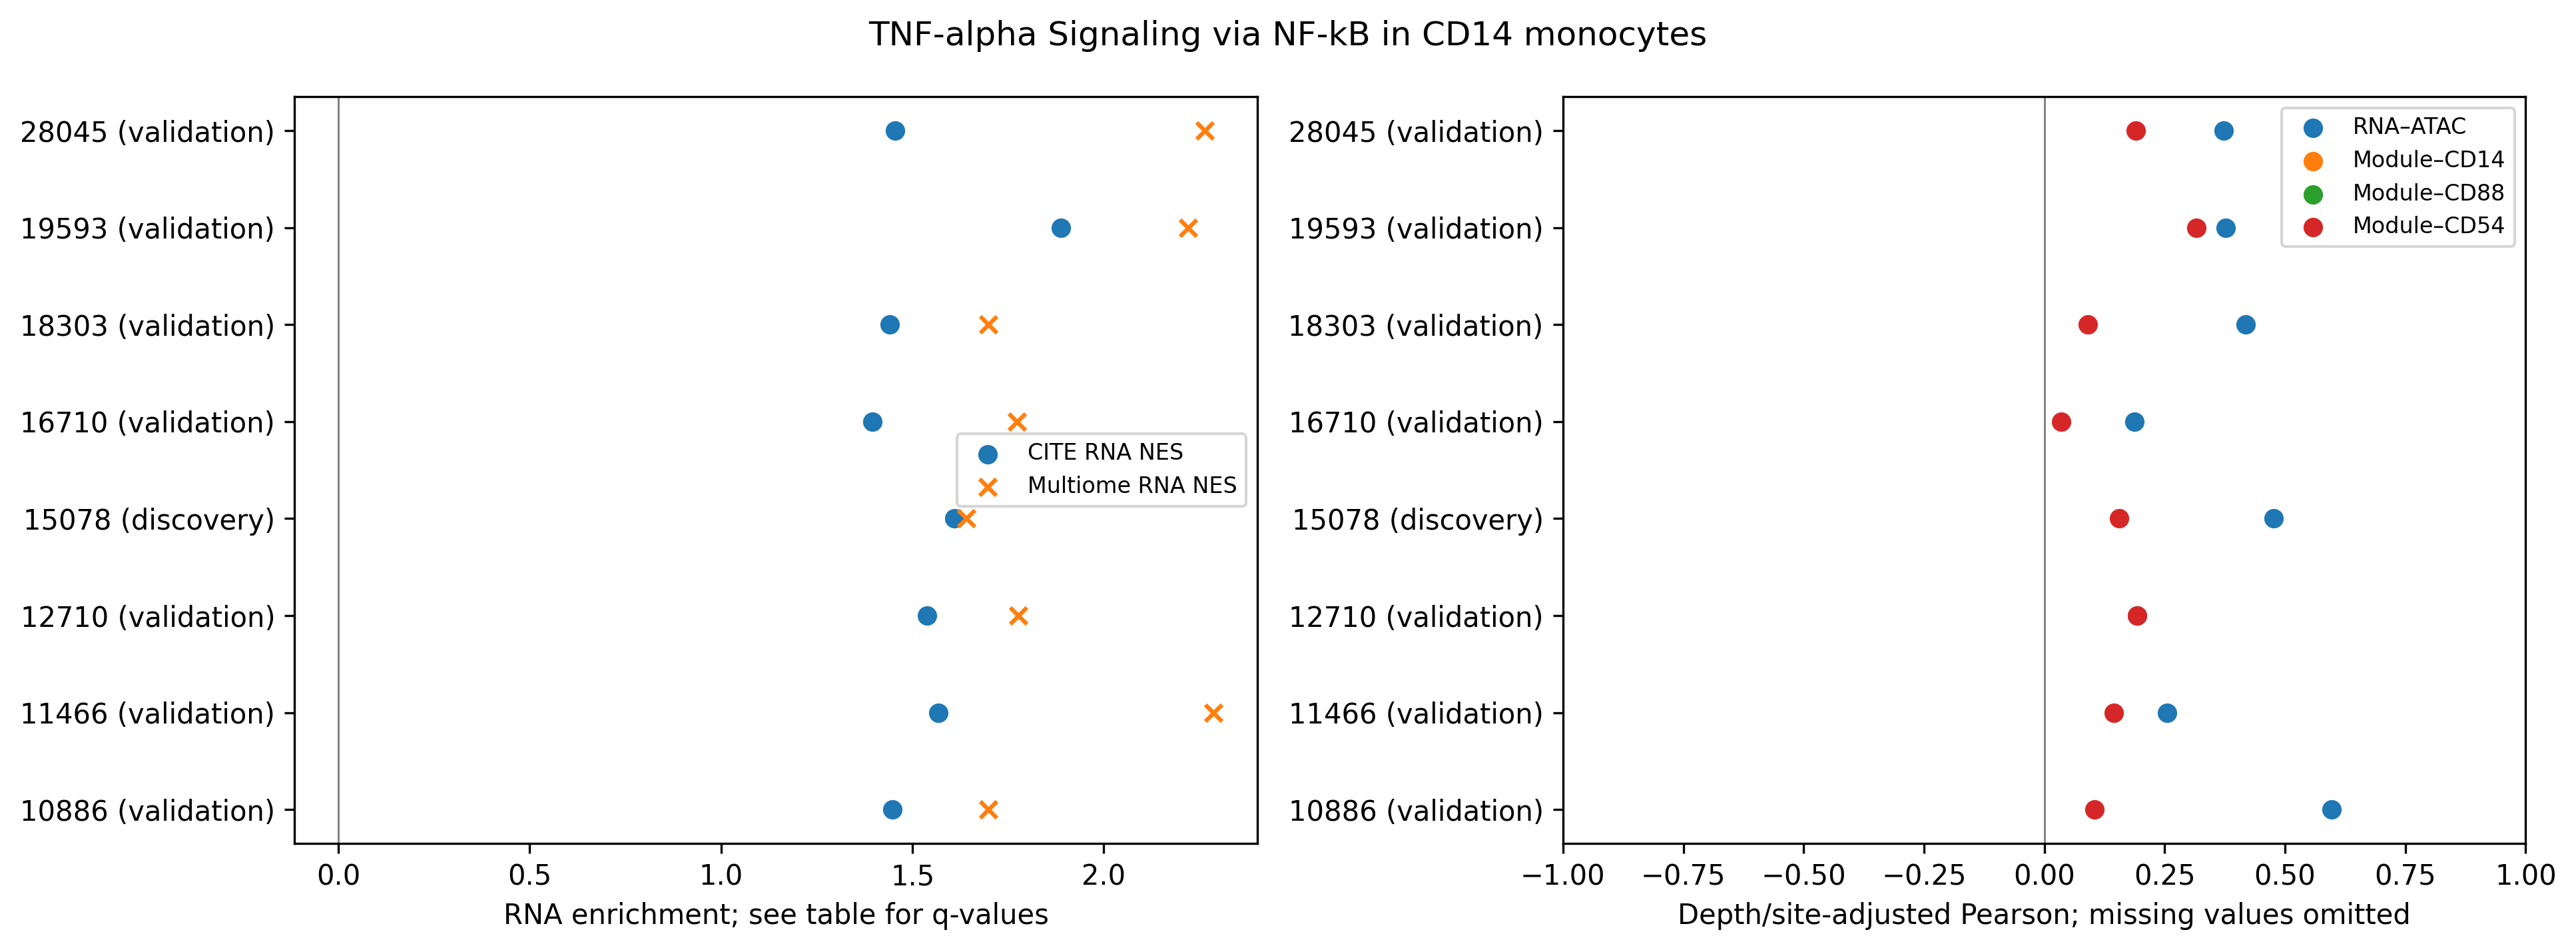

In [4]:
evidence, validation_summary = run_cross_donor(
    PATHS, DISCOVERY, OUTPUT, min_cells=MIN_CELLS,
    permutations=PERMUTATIONS, seed=SEED)
with pd.option_context('display.max_columns', None):
    display(evidence)
    display(validation_summary)
for path in sorted(OUTPUT.glob('donor_evidence_*.png')):
    display(Image(filename=str(path)))

## Inspect site sensitivity and matched-gene removal
Compare RNA only between matching donor/site/capture groups; sites unique to one
capture cannot establish cross-capture replication. Site strata are not extra donors.
An effect consistent in sign may still be negligible: inspect magnitudes and missing
groups. The table below includes all per-donor site results for the two targets.

In [5]:
from src.cross_donor import PROGRAMS
site_tables, loo_tables = [], []
for folder in sorted(OUTPUT.glob('donor_*')):
    if not folder.is_dir():
        continue
    donor = folder.name.removeprefix('donor_')
    for capture in ['cite', 'multiome']:
        t = pd.read_csv(folder / f'{capture}_enrichment.csv')
        t = t[t.pathway.isin(PROGRAMS)].assign(donor=donor, capture=capture)
        site_tables.append(t)
        display(pd.read_csv(folder / f'{capture}_rna_site_coverage.csv').assign(donor=donor, capture=capture))
    loo_tables.append(pd.read_csv(folder / 'protein_leave_one_out.csv').assign(donor=donor))
sites = pd.concat(site_tables, ignore_index=True)
loo = pd.concat(loo_tables, ignore_index=True)
sites.to_csv(OUTPUT / 'selected_rna_site_results.csv', index=False)
loo.to_csv(OUTPUT / 'all_donor_leave_one_out.csv', index=False)
with pd.option_context('display.max_rows', None):
    display(sites[['donor', 'capture', 'site', 'pathway', 'NES', 'q_value', 'n_null_same_sign']])
    display(loo)

,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,726,NaN,10886,cite
1,site1,True,726,NaN,10886,cite


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,704,NaN,10886,multiome
1,site1,True,704,NaN,10886,multiome


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,6056,NaN,11466,cite
1,site3,True,6056,NaN,11466,cite


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,674,NaN,11466,multiome
1,site3,True,674,NaN,11466,multiome


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,1294,NaN,12710,cite
1,site2,True,1294,NaN,12710,cite


...

,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,458,NaN,19593,multiome
1,site4,True,458,NaN,19593,multiome


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,2927,NaN,28045,cite
1,site3,True,2927,NaN,28045,cite


,site,tested,n_target,missing_reference_types,donor,capture
0,ALL,True,208,NaN,28045,multiome
1,site3,True,208,NaN,28045,multiome


,donor,capture,site,pathway,NES,q_value,n_null_same_sign
0,10886,cite,ALL,Inflammatory Response,1.433889,0.010305,996
1,10886,cite,ALL,TNF-alpha Signaling via NF-kB,1.446872,0.010305,999
2,10886,cite,site1,Inflammatory Response,1.433889,0.010305,996
3,10886,cite,site1,TNF-alpha Signaling via NF-kB,1.446872,0.010305,999
4,10886,multiome,ALL,Inflammatory Response,1.768258,0.019238,848
5,10886,multiome,ALL,TNF-alpha Signaling via NF-kB,1.697793,0.019238,889
6,10886,multiome,site1,Inflammatory Response,1.768258,0.019238,848
7,10886,multiome,site1,TNF-alpha Signaling via NF-kB,1.697793,0.019238,889
8,11466,cite,ALL,Inflammatory Response,1.518825,0.008945,986
9,11466,cite,ALL,TNF-alpha Signaling via NF-kB,1.567503,0.008945,992


,pathway,adt,gene,site,n_cells,full_adjusted,loo_adjusted,status,donor
0,Inflammatory Response,CD14,CD14,ALL,726,0.310624,0.302227,tested,10886
1,Inflammatory Response,CD14,CD14,site1,726,0.310624,0.302227,tested,10886
2,Inflammatory Response,CD88,C5AR1,ALL,726,0.332883,0.306522,tested,10886
3,Inflammatory Response,CD88,C5AR1,site1,726,0.332883,0.306522,tested,10886
4,Inflammatory Response,CD54,ICAM1,ALL,726,0.182044,0.177470,tested,10886
5,Inflammatory Response,CD54,ICAM1,site1,726,0.182044,0.177470,tested,10886
6,TNF-alpha Signaling via NF-kB,CD54,ICAM1,ALL,726,0.104120,0.101060,tested,10886
7,TNF-alpha Signaling via NF-kB,CD54,ICAM1,site1,726,0.104120,0.101060,tested,10886
8,Inflammatory Response,CD14,CD14,ALL,6056,0.174503,0.168358,tested,11466
9,Inflammatory Response,CD14,CD14,site3,6056,0.174503,0.168358,tested,11466


## Pseudobulk: sum versus mean
Each donor folder has `pseudobulk_cite/` and `pseudobulk_multiome/`:

- `raw_count_sums.npz`: integer **sums of raw GEX counts**, rows indexed by samples.csv,
  columns by genes.csv. Groups preserve donor, site and harmonized cell type.
- `samples.csv`: cell count, total library count and >=50-cell eligibility flag.
  Small groups remain exported but must be filtered before downstream inference.
- `sum_log1p_cp10k.npz`: normalized summed counts, descriptive only.
- `mean_cell_log1p_cp10k.npz`: average normalized single-cell expression, a distinct
  descriptive output. It is not count-based pseudobulk.

Pseudobulk includes all resolved types within eligible donors, not just CD14 or the
common validation reference. Unresolved cells are excluded. Matrices remain separate
by capture because panels differ. For later count models, use raw_count_sums with
an appropriate design and library offsets/normalization. Do not treat donor-site
rows as independent people. No DESeq2/edgeR hypothesis test is performed here.
Processed ATAC activity and normalized ADTs are not exported as RNA-like count sums.

In [6]:
samples = []
for folder in sorted(OUTPUT.glob('donor_*')):
    if folder.is_dir():
        for capture in ['cite', 'multiome']:
            samples.append(pd.read_csv(folder / f'pseudobulk_{capture}/samples.csv').assign(capture=capture))
display(pd.concat(samples, ignore_index=True).groupby(['donor', 'capture', 'eligible_min_cells']).size().rename('n_groups').reset_index())

,donor,capture,eligible_min_cells,n_groups
0,10886,cite,False,3
1,10886,cite,True,12
2,10886,multiome,False,4
3,10886,multiome,True,11
4,11466,cite,False,1
5,11466,cite,True,14
6,11466,multiome,False,6
7,11466,multiome,True,7
8,12710,cite,False,1
9,12710,cite,True,13


## Main findings
No cross-donor result is pre-filled. First count eligible validation donors excluding
15078. Then assess positive RNA enrichment in both captures, adjusted associations,
site variation, leave-one-out persistence and unmeasured groups. Report donor effects
individually; medians and sign counts weight donors equally and are descriptive.
If only discovery is eligible, this run supplies no independent replication.

## Limitations
The programs and readouts were selected in donor 15078. Frozen discovery gene filtering
can limit sensitivity elsewhere. A smaller common reference changes the estimand,
so nb04 values need not reproduce numerically. Cell-level correlations are not
donor-level tests; the number and site structure of donors determine later inference.
Unknown ATAC preprocessing, limited ADT panel, possible background and correlated
module genes remain limitations. No causal, disease/control or latent integration
claim is made. Inspect results before planning a pooled statistical model.